# Simulation comparison : Zeeman slower usecase

We test the simulations on the configuration from Feng et al 2024 Quantum Sci. Technol. 9 025017

## Import configuration

In [1]:
# -- IMPORTS
# generic
import numpy as np
import matplotlib.pyplot as plt

# atomsmltr
from atomsmltr.simulation import RK4, ScipyIVP_3D, Euler
from atomsmltr.examples.feng2024 import config

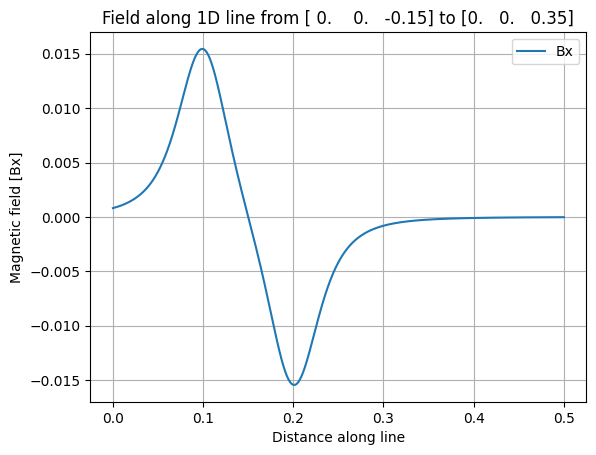

<Axes: title={'center': 'Field along 1D line from [ 0.    0.   -0.15] to [0.   0.   0.35]'}, xlabel='Distance along line', ylabel='Magnetic field [Bx]'>

In [2]:
# -- SHOW CONFIG INFORMATION
# all informations
# config.print_info()  # output is long, uncomment if needed

# show magnetic field
mag_field = config.get_magnetic_field_copy("Symmetric Permanent Magnet Configuration")
mag_field.plot1D(
    start=[0, 0, -0.150],
    stop=[0, 0, 0.350],
    Npoints=1000,
    component="Bx",
    space_scale=1e0,
    show=True,
)

## Testing integrators accuracy

### Settings

In [28]:
# -- Prepare simulations
# settings
t = np.linspace(0, 0.04, 2_000)
u0 = np.array([0, 0, -0.15, 0, 0, 300])
results = {}

### Tests

In [29]:
sim = RK4(config)
res = sim.integrate(u0, t)
results["RK4"] = res
ref = res

In [30]:
sim = ScipyIVP_3D(config, method="RK45")
res = sim.integrate(u0, t)
results["Scipy_RK45"] = res

In [31]:
sim = ScipyIVP_3D(config, method="Radau")
res = sim.integrate(u0, t)
results["Scipy_Radau"] = res

In [35]:
sim = ScipyIVP_3D(config, method="DOP853")
res = sim.integrate(u0, t)
results["Scipy_DOP853"] = res

In [36]:
sim = ScipyIVP_3D(config, method="BDF")
res = sim.integrate(u0, t)
results["Scipy_BDF"] = res

In [38]:
sim = ScipyIVP_3D(config, method="LSODA")
res = sim.integrate(u0, t)
results["Scipy_LSODA"] = res

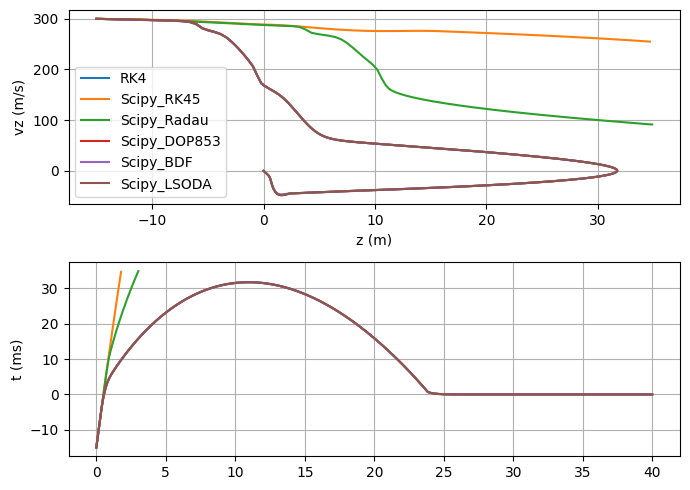

In [39]:
fig, ax = plt.subplots(2, 1, figsize=(7,5), tight_layout=True)
for label, res in results.items():
    ax[0].plot(res.y[2,:] * 100, res.y[5,:], label=label)
    ax[1].plot(res.t * 1e3, res.y[2,:] * 100, label=label)

ax[0].set_ylabel("vz (m/s)")
ax[0].set_xlabel("z (m)")
ax[0].legend()
ax[1].set_ylabel("z (cm)")
ax[1].set_ylabel("t (ms)")
for cax in ax:
    cax.grid()
plt.show()

### Time

In [42]:
sim = RK4(config)
res = sim.integrate(u0, t)
%timeit res = sim.integrate(u0, t)

5.79 s ± 564 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
for method in ["RK45", "Radau", "DOP853", "BDF", "LSODA"]:
    print("> " + method)
    for vectorized in [False, True]:
        sim = ScipyIVP_3D(config, method=method)
        %timeit res = sim.integrate(u0, t)
    

> RK45
